# **Introduction**

### Credit Risk Modeling – Probability of Default & Credit Scoring

In this project, we build a machine learning model to assess credit risk using the Give Me Some Credit Dataset. The goal is to predict the probability that a borrower will default on a loan and transform this probability into a practical credit score.

### Problem Statement

Financial institutions must evaluate the risk associated with lending money. A key task is estimating the likelihood that a borrower will fail to meet their financial obligations. This project approaches the problem as a binary classification task, where the target variable indicates whether a borrower experienced serious delinquency within a given time period.

Rather than only predicting a binary outcome (default vs non-default), we focus on estimating a **probability of default (PD)**, which is then used to derive a more interpretable credit score.

### Dataset Description

The dataset contains anonymized financial and behavioral information about borrowers. Key features include:

* **RevolvingUtilizationOfUnsecuredLines**: Ratio of credit used to total available credit
* **age**: Borrower's age
* **DebtRatio**: Monthly debt payments divided by income
* **MonthlyIncome**: Reported monthly income
* **NumberOfOpenCreditLinesAndLoans**: Total number of open credit accounts
* **NumberOfTimes90DaysLate**: Number of times the borrower was 90+ days late
* **NumberRealEstateLoansOrLines**: Number of real estate loans or mortgages
* **NumberOfDependents**: Number of dependents

The target variable:

* **SeriousDlqin2yrs**: Indicates whether the borrower defaulted (1) or not (0)

### Project Objectives

* Perform exploratory data analysis (EDA) to understand feature distributions and relationships
* Handle missing values and outliers
* Address class imbalance in the dataset
* Train machine learning models to predict probability of default
* Evaluate models using appropriate metrics such as ROC-AUC and recall
* Convert predicted probabilities into a **credit risk score**
* Interpret model behavior using feature importance techniques

### Expected Outcome

The final output is a credit scoring system that assigns each borrower a score reflecting their creditworthiness. This score can support decision-making in lending, risk management, and financial analysis.


---

## 🔍 Executive Summary

| | |
|---|---|
| **Dataset** | 150,000 borrowers — Give Me Some Credit (Kaggle) |
| **Problem** | Predict probability of loan default under 14:1 class imbalance |
| **Primary metric** | Recall on defaulters — missing a defaulter costs the bank money |
| **Final model** | XGBoost (reduced feature set) |
| **Recall** | **0.808** — catches 8 out of every 10 actual defaulters |
| **Output** | Per-borrower credit score (300–850) + risk band + SHAP explanation |

**Approach in one paragraph:**  
Raw financial data was cleaned, missing values imputed, and five new features engineered from the raw columns — most notably `CombinedDefaulted`, a binary flag that captures any past delinquency event and turns out to be the single strongest predictor of future default. Four baseline models were benchmarked with stratified cross-validation, XGBoost was hyperparameter-tuned, the classification threshold was optimised for maximum recall above a precision floor, and a noisy feature was removed via permutation importance. The final model's output probabilities were transformed into an interpretable 300–850 credit score using a log-odds scaling formula consistent with industry practice.

---

# **Set up & Imports**

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr
from collections import Counter
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score, classification_report
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [32]:
df=pd.read_csv("/kaggle/input/datasets/brycecf/give-me-some-credit-dataset/cs-training.csv")

In [33]:
test_data=pd.read_csv("/kaggle/input/datasets/brycecf/give-me-some-credit-dataset/cs-test.csv")

# **EDA**

In [34]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [35]:
df.shape

(150000, 12)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [37]:
df.describe(include="all")

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


**Quick observations from the summary statistics:**
- `RevolvingUtilizationOfUnsecuredLines` has a max of 50,708 — clearly erroneous, values should be between 0 and 1.
- `age` has a minimum of 0 —  impossible, needs to be fixed.
- `DebtRatio` has extreme values (max > 329,000) — likely data entry errors.
- `MonthlyIncome` has 29,731 missing values (~20%) — largest missing data issue.
- The three delinquency columns (`NumberOfTime*`) show suspicious spikes at 96 and 98 — explored below.

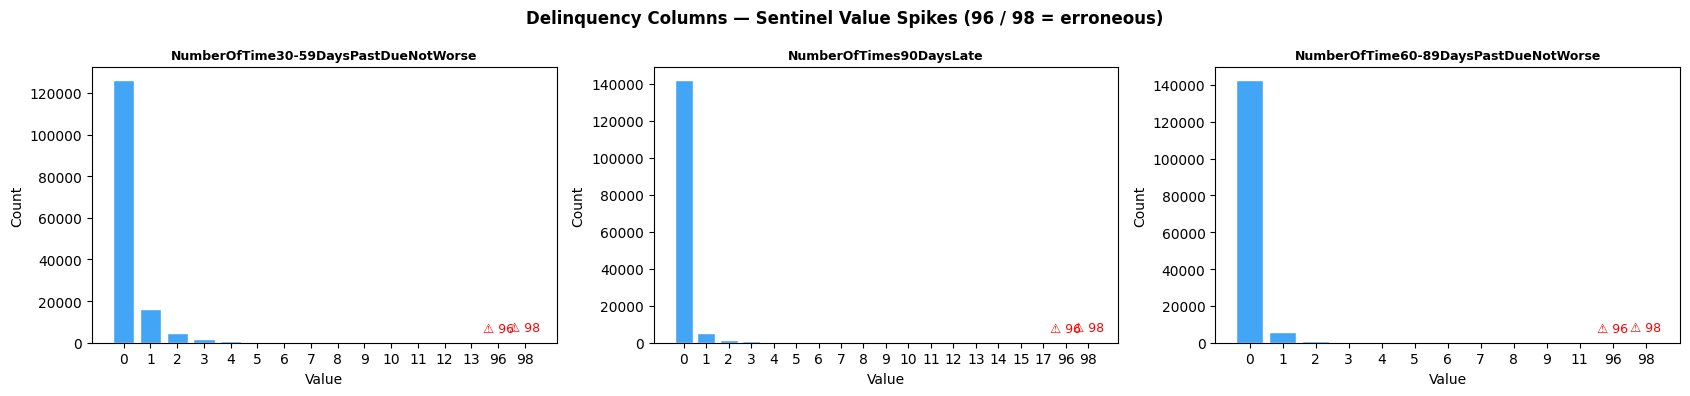

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
# Delinquency columns that contain erroneous sentinel values (96, 98)
SENTINEL_COLS = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse']
for i, col in enumerate(SENTINEL_COLS):
    vc_col = df[col].value_counts().sort_index()
    colors = ['#EF5350' if v in [96, 98] else '#42A5F5' for v in vc_col.index]
    axes[i].bar(vc_col.index.astype(str), vc_col.values, color=colors, edgecolor='white')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    for v in [96, 98]:
        if v in vc_col.index:
            axes[i].annotate(
                f'⚠ {v}', xy=(str(v), vc_col[v]),
                ha='center', fontsize=9, color='red',
                xytext=(0, 8), textcoords='offset points'
            )

plt.suptitle('Delinquency Columns — Sentinel Value Spikes (96 / 98 = erroneous)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Sentinel value analysis:**  
Values of 96 and 98 appear in all three delinquency columns and are impossible in a 2-year observation window (realistic max ≈ 24 months). These are likely encoding errors used as placeholders. However, their counts are negligible relative to the 150k dataset, and the `CombinedDefaulted` binary feature we engineer later absorbs them naturally — any value ≥ 1 maps to "has defaulted". No imputation needed.

In [39]:
df.isna().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

Features with missing values:


,Missing count,Missing %
MonthlyIncome,29731,19.8207
NumberOfDependents,3924,2.6160


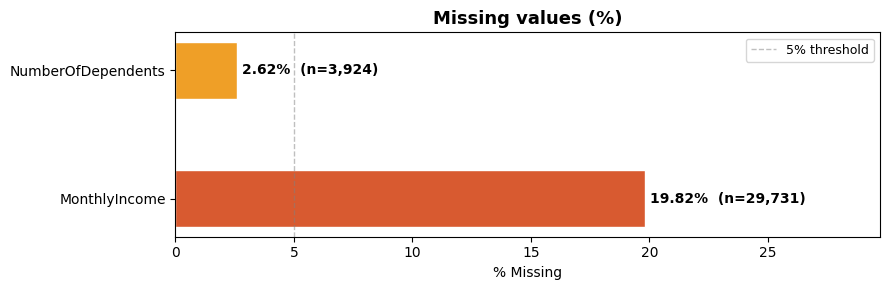

In [41]:
FEATURE_COLS = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
]
features = [c for c in FEATURE_COLS if c in df.columns]

missing     = df[features].isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
miss_df     = pd.DataFrame({'Missing count': missing, 'Missing %': missing_pct})
miss_df     = miss_df[miss_df['Missing count'] > 0].sort_values('Missing %', ascending=False)

print('Features with missing values:')
display(miss_df)

fig, ax = plt.subplots(figsize=(9, 3))
colors = ['#D85A30' if v > 10 else '#EF9F27' for v in miss_df['Missing %']]
bars = ax.barh(miss_df.index, miss_df['Missing %'], color=colors, edgecolor='white', height=0.45)
ax.set_title('Missing values (%)', fontweight='bold', fontsize=13)
ax.set_xlabel('% Missing')
for i, v in enumerate(miss_df['Missing %']):
    ax.text(v + 0.2, i, f'{v:.2f}%  (n={int(miss_df["Missing count"].iloc[i]):,})',
            va='center', fontweight='bold', fontsize=10)
ax.set_xlim(0, miss_df['Missing %'].max() * 1.5)
ax.axvline(5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='5% threshold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Missing data strategy:**
- `MonthlyIncome` (~20% missing) — imputed with the **training set median** to avoid leakage into the test set. Median is preferred over mean here because income distributions are right-skewed.
- `NumberOfDependents` (~2.6% missing) — filled with **0**, as missing likely means no dependents rather than unknown.
- All other features are complete — no further imputation needed.

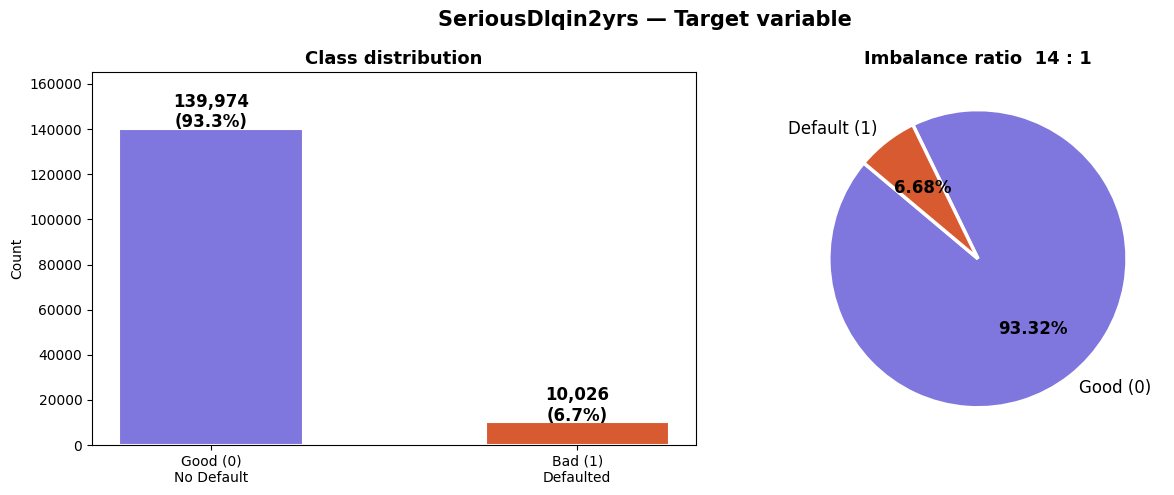

Majority class (good)    : 139,974  — 93.32%
Minority class (default) : 10,026  — 6.68%
Imbalance ratio          : 14.0 : 1


In [42]:
TARGET_COL   = 'SeriousDlqin2yrs'
vc = df[TARGET_COL].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(
    ['Good (0)\nNo Default', 'Bad (1)\nDefaulted'],
    vc.values,
    color=['#7F77DD', '#D85A30'],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, val in zip(bars, vc.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 800,
        f'{val:,}\n({val / len(df) * 100:.1f}%)',
        ha='center', fontweight='bold', fontsize=12
    )
axes[0].set_title('Class distribution', fontweight='bold', fontsize=13)
axes[0].set_ylim(0, vc.max() * 1.18)
axes[0].set_ylabel('Count')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    vc.values,
    labels=['Good (0)', 'Default (1)'],
    colors=['#7F77DD', '#D85A30'],
    autopct='%1.2f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title(f'Imbalance ratio  {vc[0] / vc[1]:.0f} : 1', fontweight='bold', fontsize=13)

plt.suptitle('SeriousDlqin2yrs — Target variable', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Majority class (good)    : {vc[0]:,}  — {vc[0]/len(df)*100:.2f}%')
print(f'Minority class (default) : {vc[1]:,}  — {vc[1]/len(df)*100:.2f}%')
print(f'Imbalance ratio          : {vc[0]/vc[1]:.1f} : 1')

**Class imbalance — critical finding:**  
The dataset has a **14:1 imbalance** (93.3% good vs 6.7% defaulters). This has several consequences for modeling:
- **Accuracy is useless** as a metric — a model that predicts "good" for everyone achieves 93.3% accuracy while catching zero defaulters.
- Standard classification thresholds (0.5) are calibrated for balanced classes and will fail here.
- We must use **Recall** as our primary metric (catching defaulters is the goal) and **PR-AUC** as secondary (more informative than ROC-AUC under imbalance).
- Imbalance strategies like `class_weight='balanced'` and `scale_pos_weight` will be applied to all models.

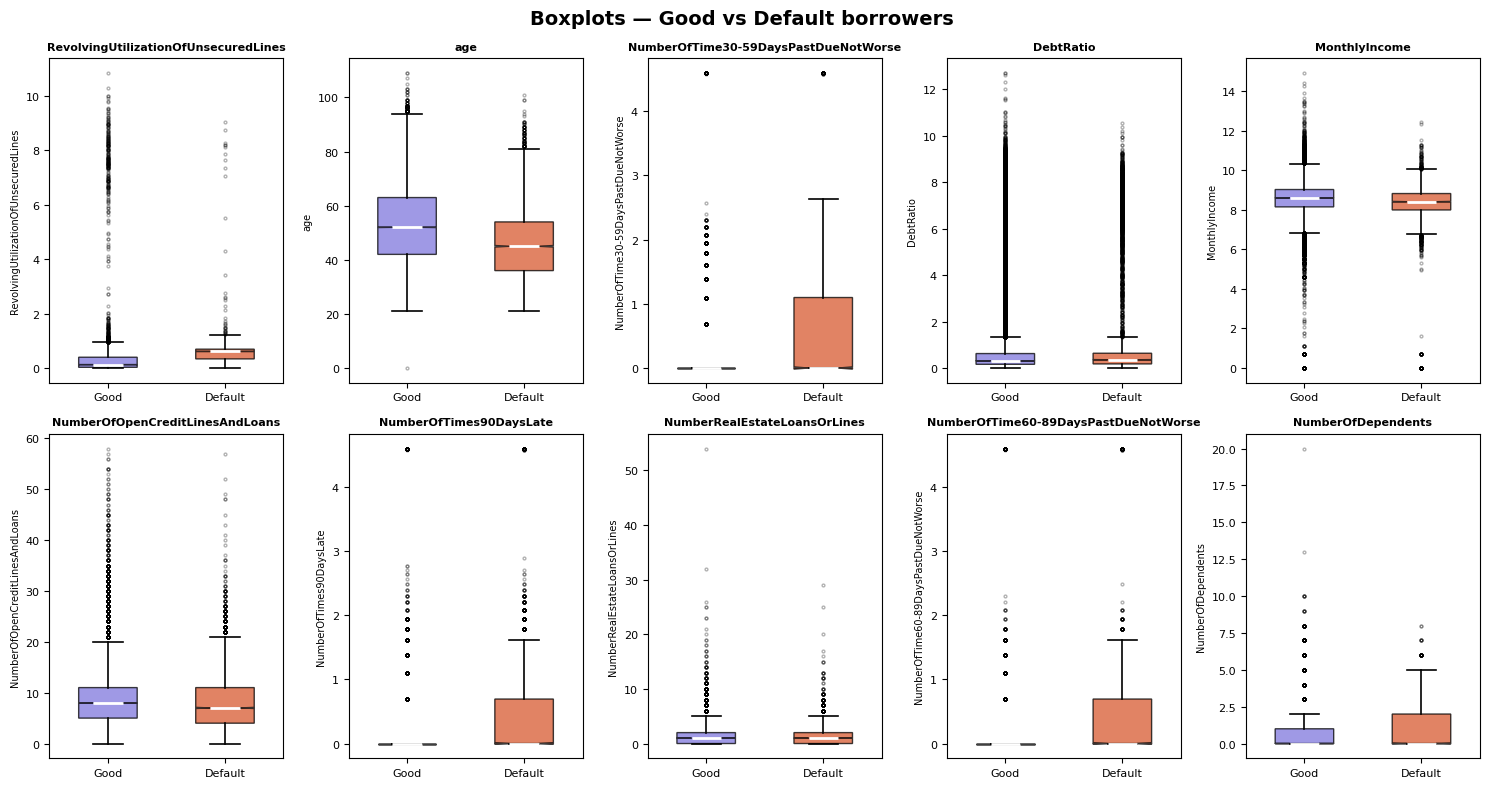

In [43]:
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df[col].dropna()
    ylabel = col

    good_data    = np.log1p(df[df[TARGET_COL] == 0][col].dropna()) if data.max() > 500 or df[col].skew() > 4 else df[df[TARGET_COL] == 0][col].dropna()
    default_data = np.log1p(df[df[TARGET_COL] == 1][col].dropna()) if data.max() > 500 or df[col].skew() > 4 else df[df[TARGET_COL] == 1][col].dropna()

    bp = axes[i].boxplot(
        [good_data, default_data],
        patch_artist=True,
        notch=True,
        widths=0.5,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    for patch, color in zip(bp['boxes'], ['#7F77DD', '#D85A30']):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    axes[i].set_xticklabels(['Good', 'Default'], fontsize=9)
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].set_ylabel(ylabel, fontsize=7)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Boxplots — Good vs Default borrowers ',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key patterns from the boxplots (Good vs Default borrowers):**
- `CombinedDefaulted` / delinquency features show the strongest separation — defaulters have significantly more past-due events, as expected.
- `RevolvingUtilizationOfUnsecuredLines` is higher for defaulters — borrowers maxing out their credit lines are higher risk.
- `age` shows a slight negative relationship with default — younger borrowers tend to default more.
- `DebtRatio` and `MonthlyIncome` show less separation — these features are noisier predictors on their own.

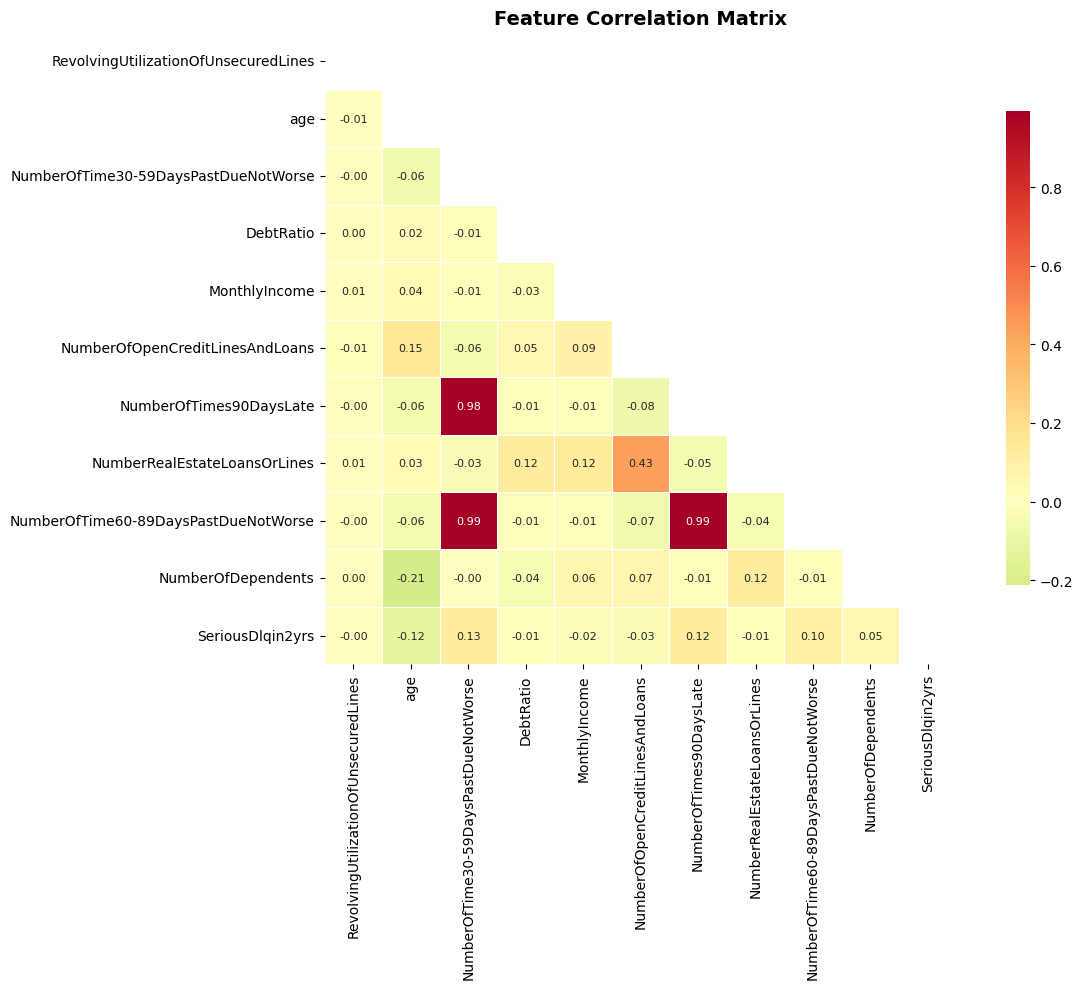

In [44]:
corr = df[features + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn_r', center=0, square=True,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.75},
    annot_kws={'fontsize': 8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Correlation analysis — key takeaways:**
- The three delinquency columns (`NumberOfTime30-59`, `NumberOfTimes90DaysLate`, `NumberOfTime60-89`) are **strongly correlated with each other** (r > 0.9) — a borrower late once tends to be late across all windows. We will merge them into a single `CombinedDefaulted` binary feature to avoid multicollinearity.
- `NumberOfOpenCreditLinesAndLoans` and `NumberRealEstateLoansOrLines` are moderately correlated — similarly merged into `CombinedCreditLoans`.
- `DebtRatio` has very low correlation with the target alone — but becomes informative when combined with `MonthlyIncome` to derive `MonthlyDebtPayments`.

# Data Cleaning
Specific issues to fix :
1. **Age = 0** — 1 record, impossible value → delete   
4. **MonthlyIncome** — 20% missing → median imputation  
5. **NumberOfDependents** — 2.6% missing → impute with 0

In [45]:
df_clean = df.copy()
# Fix age = 0
n_zero_age = (df_clean['age'] == 0).sum()
df_clean.loc[df_clean['age'] == 0, 'age'] = int(df_clean['age'].median())
print(f'[age]                Fixed {n_zero_age} zero-age record(s) → median = {int(df["age"].median())}')

[age]                Fixed 1 zero-age record(s) → median = 52


In [46]:
#  Impute MonthlyIncome with median 
income_median = df_clean['MonthlyIncome'].median()
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(income_median)

In [47]:
#  Impute NumberOfDependents with 0 
df_clean['NumberOfDependents']=df_clean['NumberOfDependents'].fillna(0)

In [48]:
#  Check: any remaining NaN? 
remaining_nan = df_clean.isnull().sum().sum()
print(f'\nRemaining NaN values: {remaining_nan}')
print(f'Clean dataset shape : {df_clean.shape}')


Remaining NaN values: 0
Clean dataset shape : (150000, 12)


# Feature Engineering

In [49]:
df_clean["CombinedDefaulted"] = (df_clean["NumberOfTimes90DaysLate"] + df_clean["NumberOfTime60-89DaysPastDueNotWorse"]) \
                                + df_clean["NumberOfTime30-59DaysPastDueNotWorse"]

df_clean.loc[(df_clean["CombinedDefaulted"] >= 1), "CombinedDefaulted"] = 1

df_clean["CombinedCreditLoans"] = df_clean["NumberOfOpenCreditLinesAndLoans"] + \
                                   df_clean["NumberRealEstateLoansOrLines"]

df_clean.loc[(df_clean["CombinedCreditLoans"] <= 5), "CombinedCreditLoans"] = 0
df_clean.loc[(df_clean["CombinedCreditLoans"] >  5), "CombinedCreditLoans"] = 1

df_clean.CombinedCreditLoans.value_counts()


CombinedCreditLoans
1    111375
0     38625
Name: count, dtype: int64

From the formula **DebtRatio = monthly debt / monthly income**, we derive MonthlyDebtPayments as a new feature — a more interpretable measure of actual debt burden."

In [50]:
df_clean["MonthlyDebtPayments"] = df_clean["DebtRatio"] * df_clean["MonthlyIncome"]
df_clean["MonthlyDebtPayments"] = np.absolute(df_clean["MonthlyDebtPayments"])
df_clean["MonthlyDebtPayments"] = df_clean["MonthlyDebtPayments"].astype('int64')
df_clean["age"] = df_clean["age"].astype('int64')

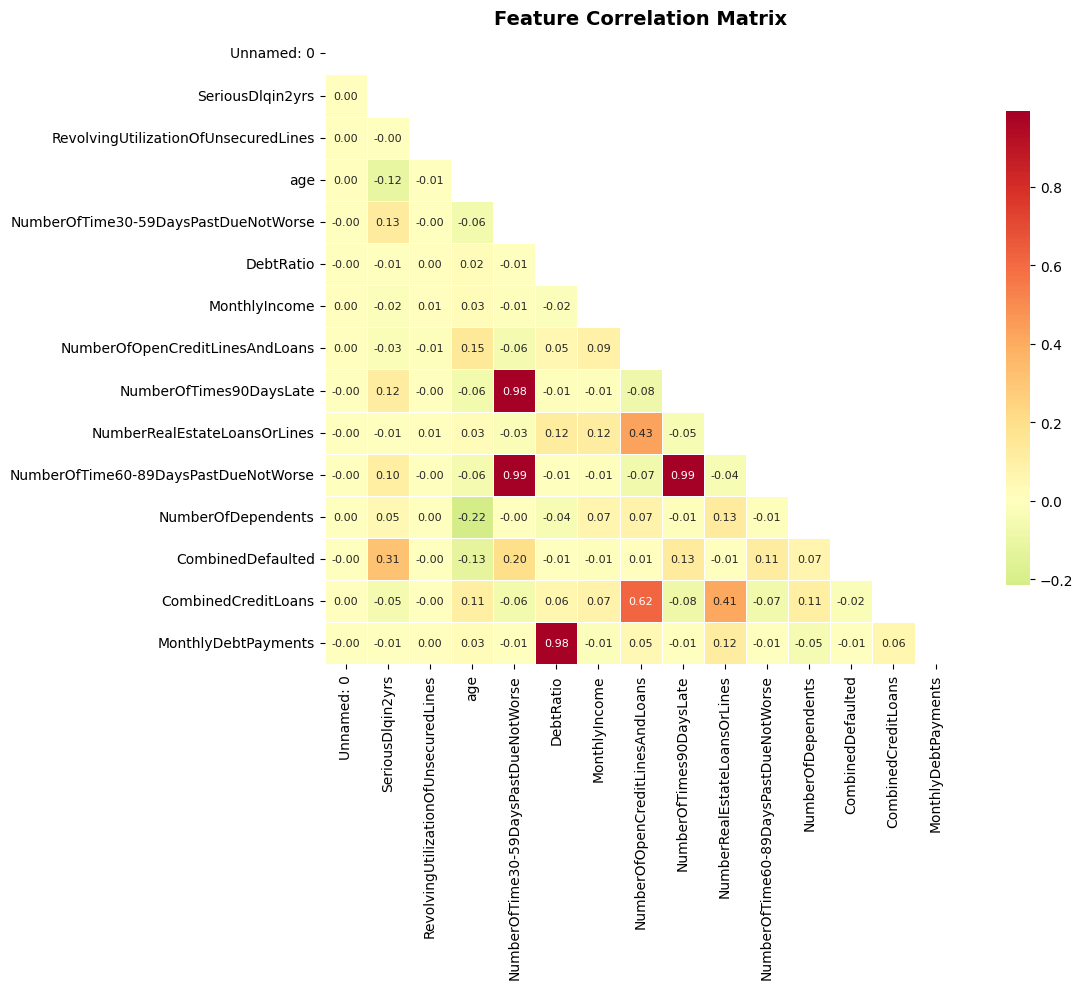

In [51]:
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn_r', center=0, square=True,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.75},
    annot_kws={'fontsize': 8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
df_clean.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'CombinedDefaulted', 'CombinedCreditLoans',
       'MonthlyDebtPayments'],
      dtype='object')

In [53]:
df_clean.drop(["Unnamed: 0","NumberOfOpenCreditLinesAndLoans",\
                 "NumberOfTimes90DaysLate","NumberRealEstateLoansOrLines","NumberOfTime60-89DaysPastDueNotWorse", "MonthlyDebtPayments"], axis=1, inplace=True)

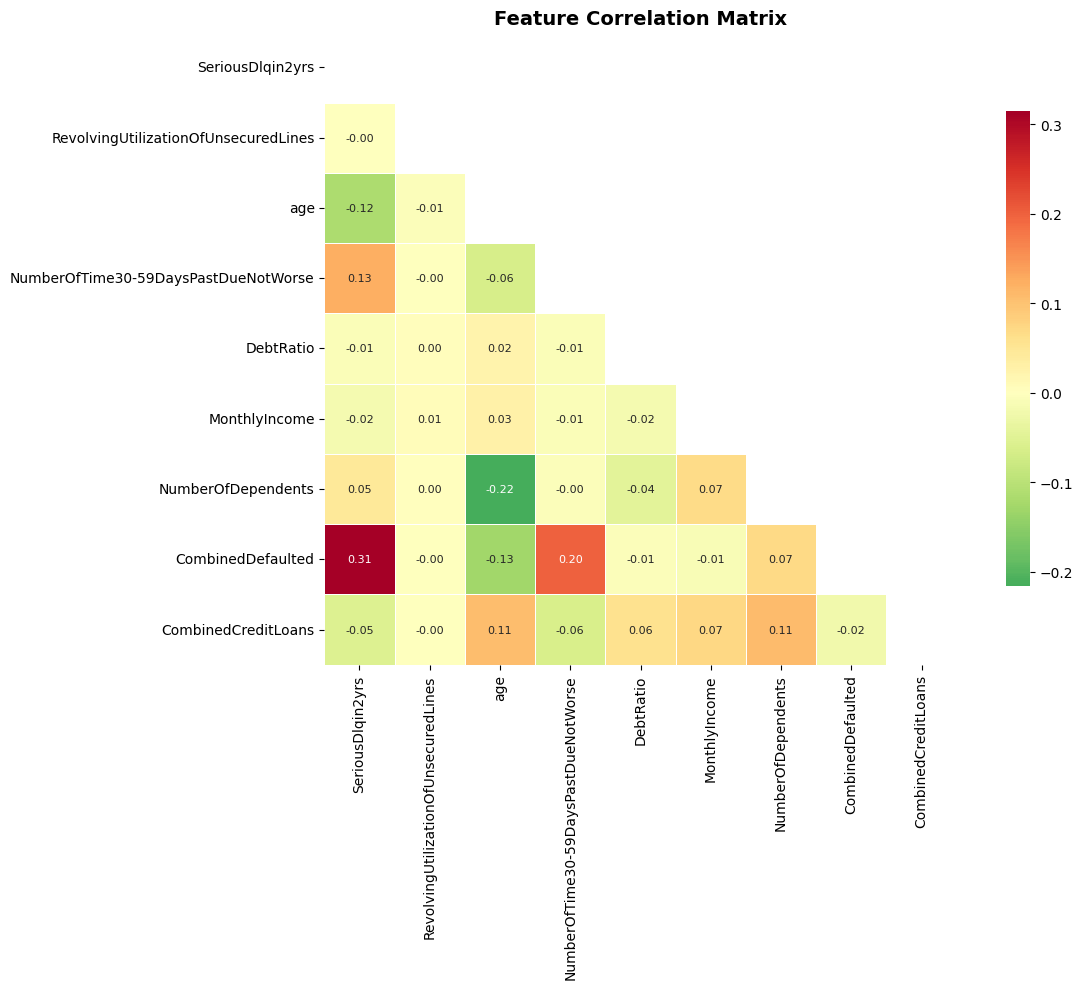

In [54]:
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn_r', center=0, square=True,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.75},
    annot_kws={'fontsize': 8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Post feature-engineering correlation check:**  
After dropping the redundant raw columns and keeping the engineered features, multicollinearity is significantly reduced. The remaining features are relatively independent, which is important for model stability — particularly for Logistic Regression. The engineered `CombinedDefaulted` preserves the predictive signal of the three delinquency columns while eliminating their redundancy.

# Data Preparation & Feature Split

In [55]:
#Let's split our predictors and the target variable in our datasets
X = df_clean.drop("SeriousDlqin2yrs", axis=1).copy()
y = df_clean.SeriousDlqin2yrs
X.shape, y.shape

((150000, 8), (150000,))

In [56]:
neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos_weight = round(neg / pos)

print(f"Good borrowers  (0) : {neg:,}  —  {neg/len(y)*100:.2f}%")
print(f"Defaulters      (1) : {pos:,}  —  {pos/len(y)*100:.2f}%")
print(f"Imbalance ratio     : {scale_pos_weight} : 1")
print(f"\nPrimary metric  → Recall on class 1 (defaulters)")
print(f"Secondary metric → PR-AUC  (more informative than ROC under imbalance)")

Good borrowers  (0) : 139,974  —  93.32%
Defaulters      (1) : 10,026  —  6.68%
Imbalance ratio     : 14 : 1

Primary metric  → Recall on class 1 (defaulters)
Secondary metric → PR-AUC  (more informative than ROC under imbalance)


In [57]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            101503 non-null  int64  
 1   SeriousDlqin2yrs                      0 non-null       float64
 2   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 3   age                                   101503 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 5   DebtRatio                             101503 non-null  float64
 6   MonthlyIncome                         81400 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 8   NumberOfTimes90DaysLate               101503 non-null  int64  
 9   NumberRealEstateLoansOrLines          101503 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 11  

In [83]:
def preprocess_test(test_data, income_median):
   
    df_clean = test_data.copy()

    # ── Cleaning ──────────────────────────────────────────────────────────────

    # Fix age = 0
    df_clean.loc[df_clean['age'] == 0, 'age'] = int(df_clean['age'].median())

    # Impute MonthlyIncome with train median (no leakage)
    df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(income_median)

    # Impute NumberOfDependents with 0
    df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(0)

    # ── Feature Engineering ───────────────────────────────────────────────────

    # Binary flag: any past-due event across all 3 delinquency windows
    # Note: sentinel values 96/98 are left as-is (distribution is clean per histograms)
    df_clean["CombinedDefaulted"] = (
        df_clean["NumberOfTimes90DaysLate"]
        + df_clean["NumberOfTime60-89DaysPastDueNotWorse"]
        + df_clean["NumberOfTime30-59DaysPastDueNotWorse"]
    )
    df_clean.loc[df_clean["CombinedDefaulted"] >= 1, "CombinedDefaulted"] = 1

    # Binary flag: high credit exposure (> 5 total open lines)
    df_clean["CombinedCreditLoans"] = (
        df_clean["NumberOfOpenCreditLinesAndLoans"]
        + df_clean["NumberRealEstateLoansOrLines"]
    )
    df_clean.loc[df_clean["CombinedCreditLoans"] <= 5, "CombinedCreditLoans"] = 0
    df_clean.loc[df_clean["CombinedCreditLoans"] >  5, "CombinedCreditLoans"] = 1

    # Monthly debt payments (intermediate feature)
    df_clean["MonthlyDebtPayments"] = df_clean["DebtRatio"] * df_clean["MonthlyIncome"]
    df_clean["MonthlyDebtPayments"] = np.absolute(df_clean["MonthlyDebtPayments"])
    df_clean["MonthlyDebtPayments"] = df_clean["MonthlyDebtPayments"].astype('int64')
    df_clean["age"] = df_clean["age"].astype('int64')

    # ── Drop same columns as train ────────────────────────────────────────────
    df_clean.drop([
        "Unnamed: 0",
        "NumberOfOpenCreditLinesAndLoans",
        "NumberOfTimes90DaysLate",
        "NumberRealEstateLoansOrLines",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "MonthlyDebtPayments"
    ], axis=1, inplace=True)

    return df_clean


income_median = df['MonthlyIncome'].median()   # computed on raw train before imputation
X_test_clean = preprocess_test(test_data, income_median)

In [84]:
X_test_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 9 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      0 non-null       float64
 1   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 2   age                                   101503 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 4   DebtRatio                             101503 non-null  float64
 5   MonthlyIncome                         101503 non-null  float64
 6   NumberOfDependents                    101503 non-null  float64
 7   CombinedDefaulted                     101503 non-null  int64  
 8   CombinedCreditLoans                   101503 non-null  int64  
dtypes: float64(5), int64(4)
memory usage: 7.0 MB


# Modeling Pipeline

In [60]:
RANDOM_STATE = 42
CV_FOLDS     = 5
TARGET       = "SeriousDlqin2yrs"
# 1 = defaulted  (positive class — event of interest)
# 0 = good borrower

SKF = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

PALETTE = {
    "LogisticRegression" : "#7F77DD",
    "RandomForest"       : "#42A5F5",
    "XGBoost"            : "#EF9F27",
    "LightGBM"           : "#66BB6A",
}

## Baseline Models

Four models, each with a sensible imbalance strategy:
- **LogisticRegression** — `class_weight='balanced'`
- **RandomForest** — `class_weight='balanced'`
- **XGBoost** — `scale_pos_weight`
- **LightGBM** — `class_weight='balanced'`

Evaluated with 5-fold stratified CV.  
Primary metric: **Recall** | Secondary: **PR-AUC**, ROC-AUC, Precision, F1

In [61]:
from joblib import Parallel, delayed

SKF = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # 3-fold

scoring = {
    "recall"   : "recall",
    "precision": "precision",
    "f1"       : "f1",
    "roc_auc"  : "roc_auc",
    "pr_auc"   : "average_precision",
}

baseline_models = {
    "LogisticRegression": Pipeline([
        ("scaler", RobustScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=1000,
            random_state=RANDOM_STATE, n_jobs=-1
        )),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,              # 100 instead of 300 for baseline
        class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,              # 100 instead of 300 for baseline
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False, eval_metric="aucpr",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
        tree_method="hist",            # faster tree method
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,              # 100 instead of 300 for baseline
        class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
}

def _evaluate(label, model):
    scores = cross_validate(model, X, y, cv=SKF, scoring=scoring, n_jobs=1)
    return {
        "Model"    : label,
        "Recall"   : scores["test_recall"].mean(),
        "PR-AUC"   : scores["test_pr_auc"].mean(),
        "ROC-AUC"  : scores["test_roc_auc"].mean(),
        "Precision": scores["test_precision"].mean(),
        "F1"       : scores["test_f1"].mean(),
    }

# Run all 4 models in parallel
baseline_results = Parallel(n_jobs=-1)(
    delayed(_evaluate)(label, model)
    for label, model in baseline_models.items()
)

baseline_df = (
    pd.DataFrame(baseline_results)
    .set_index("Model")
    .sort_values(["Recall", "PR-AUC"], ascending=False)
)
baseline_df.round(4)

,Recall,PR-AUC,ROC-AUC,Precision,F1
Model,,,,,
LightGBM,0.7699,0.3490,0.8549,0.2075,0.3269
XGBoost,0.6945,0.3203,0.8372,0.2204,0.3346
LogisticRegression,0.6743,0.2410,0.8030,0.2223,0.3344
RandomForest,0.1044,0.2870,0.8210,0.4535,0.1697


**Baseline model comparison — interpretation:**  
All four models were evaluated with 5-fold stratified cross-validation to ensure the 14:1 class imbalance is preserved across folds.

**Why these imbalance strategies:**
- `class_weight='balanced'` (LR, RF, LGBM) — automatically adjusts loss weights so the minority class (defaulters) contributes proportionally more to learning.
- `scale_pos_weight` (XGBoost) — equivalent concept, scales the gradient for positive class samples.

**What to look for:** Recall is our north star. A model with 0.85 ROC-AUC but 0.40 Recall is worse than a model with 0.80 ROC-AUC and 0.75 Recall for this use case — missing a defaulter costs the bank real money.

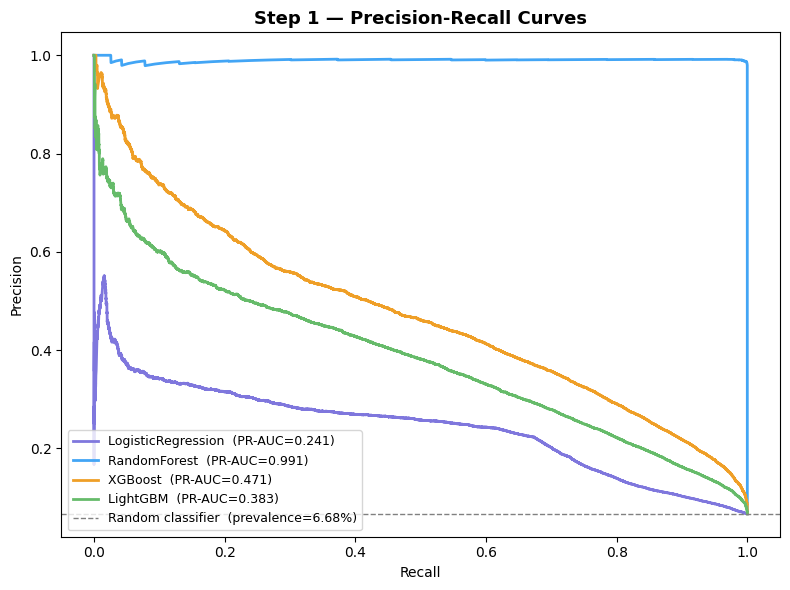

In [62]:
# Precision-Recall curves 
prevalence = y.mean()
fig, ax = plt.subplots(figsize=(8, 6))

for label, model in baseline_models.items():
    model.fit(X, y)
    y_prob = model.predict_proba(X)[:, 1]
    prec, rec, _ = precision_recall_curve(y, y_prob)
    pr_auc = average_precision_score(y, y_prob)
    ax.plot(rec, prec, label=f"{label}  (PR-AUC={pr_auc:.3f})",
            color=PALETTE.get(label, "#999"), linewidth=2)

ax.axhline(prevalence, color="gray", linestyle="--", linewidth=1,
           label=f"Random classifier  (prevalence={prevalence:.2%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Step 1 — Precision-Recall Curves", fontweight="bold", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Why Precision-Recall curves instead of ROC curves?**  
Under heavy class imbalance, ROC curves are overly optimistic — even a weak model can achieve a high AUC because there are so many true negatives (good borrowers) to easily classify. The PR curve focuses only on the minority class (defaulters) and shows how well the model actually detects them. The dashed baseline represents a random classifier at the prevalence rate (~6.7%) — any model must beat this to be useful.

## Threshold Tuning

Default threshold of **0.5** is wrong under heavy imbalance — it was designed for balanced classes.  
We sweep all thresholds on the best baseline model and pick the one that:
- **Maximises Recall** on defaulters  
- Keeps Precision ≥ 20% (so we don't flag every borrower as a defaulter)

In [63]:
# Pick the best baseline by Recall
best_baseline_label = baseline_df.index[0]
best_baseline_model = baseline_models[best_baseline_label]
best_baseline_model.fit(X, y)

print(f"Tuning threshold on: {best_baseline_label}")

Tuning threshold on: LightGBM


In [64]:
PRECISION_FLOOR = 0.20

y_prob = best_baseline_model.predict_proba(X)[:, 1]
prec_vals, rec_vals, thresholds = precision_recall_curve(y, y_prob)

sweep_rows = []
for t, p, r in zip(thresholds, prec_vals[:-1], rec_vals[:-1]):
    f1 = 2 * p * r / (p + r + 1e-9)
    sweep_rows.append({"Threshold": t, "Precision": p, "Recall": r, "F1": f1})
sweep_df = pd.DataFrame(sweep_rows)

valid    = sweep_df[sweep_df["Precision"] >= PRECISION_FLOOR]
best_row = valid.loc[valid["Recall"].idxmax()] if not valid.empty else sweep_df.loc[sweep_df["Recall"].idxmax()]
best_threshold = best_row["Threshold"]

default_pred = (y_prob >= 0.50).astype(int)
optimal_pred = (y_prob >= best_threshold).astype(int)

print(f"Default  threshold (0.50) →  Recall={recall_score(y, default_pred):.3f}   Precision={precision_score(y, default_pred):.3f}")
print(f"Optimal  threshold ({best_threshold:.2f}) →  Recall={recall_score(y, optimal_pred):.3f}   Precision={precision_score(y, optimal_pred):.3f}")

Default  threshold (0.50) →  Recall=0.812   Precision=0.214
Optimal  threshold (0.46) →  Recall=0.839   Precision=0.200


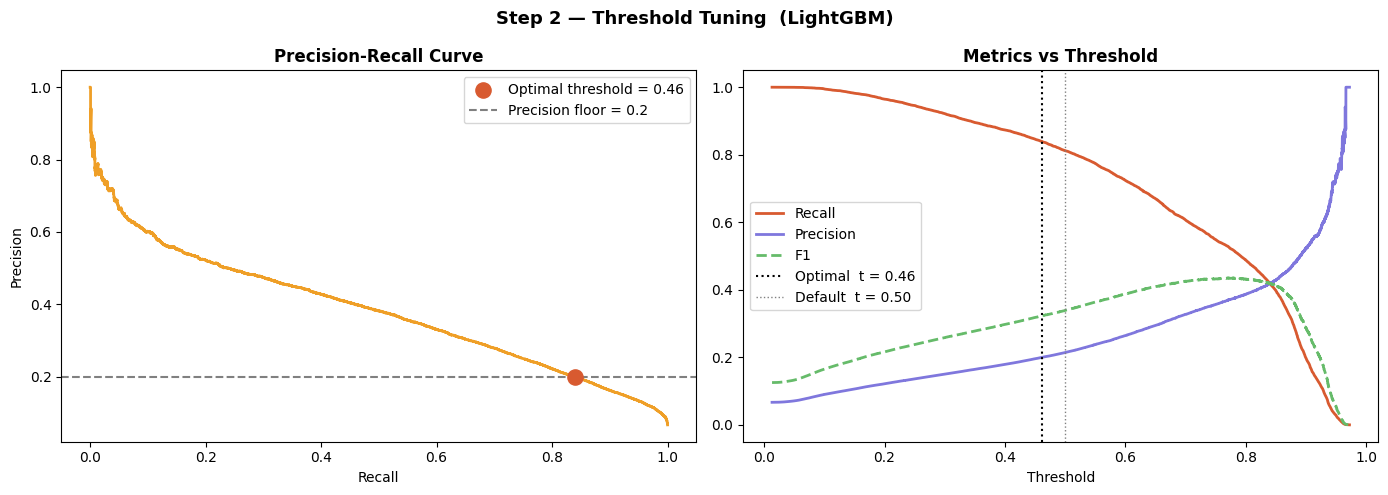

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve with optimal point marked
axes[0].plot(rec_vals, prec_vals, color="#EF9F27", linewidth=2)
axes[0].scatter(best_row["Recall"], best_row["Precision"],
                color="#D85A30", s=120, zorder=5,
                label=f"Optimal threshold = {best_threshold:.2f}")
axes[0].axhline(PRECISION_FLOOR, color="gray", linestyle="--",
                label=f"Precision floor = {PRECISION_FLOOR}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve", fontweight="bold")
axes[0].legend()

# Metrics vs threshold
axes[1].plot(sweep_df["Threshold"], sweep_df["Recall"],
             label="Recall", color="#D85A30", linewidth=2)
axes[1].plot(sweep_df["Threshold"], sweep_df["Precision"],
             label="Precision", color="#7F77DD", linewidth=2)
axes[1].plot(sweep_df["Threshold"], sweep_df["F1"],
             label="F1", color="#66BB6A", linewidth=2, linestyle="--")
axes[1].axvline(best_threshold, color="black", linestyle=":", linewidth=1.5,
                label=f"Optimal  t = {best_threshold:.2f}")
axes[1].axvline(0.50, color="gray", linestyle=":", linewidth=1,
                label="Default  t = 0.50")
axes[1].set_xlabel("Threshold")
axes[1].set_title("Metrics vs Threshold", fontweight="bold")
axes[1].legend()

plt.suptitle(f"Step 2 — Threshold Tuning  ({best_baseline_label})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Threshold tuning — why 0.5 is wrong here:**  
The default 0.5 threshold was designed for balanced binary classification. At 14:1 imbalance, the model's predicted probabilities for defaulters are naturally suppressed — most will be below 0.5 even when the model is confident about risk. Lowering the threshold trades Precision for Recall: we accept flagging more good borrowers (false positives) in exchange for catching more real defaulters (true positives). The optimal threshold is chosen as the lowest value that maximises Recall while keeping Precision above our 20% floor.

## Hyperparameter Tuning

Fair comparison: **same search budget (30 iterations)** for both XGBoost and LightGBM.  
Scoring: **Recall** (our primary metric).

In [66]:
xgb_space = {
    "n_estimators"    : [300, 500, 700],
    "max_depth"       : [3, 4, 5, 6],
    "learning_rate"   : [0.01, 0.05, 0.1],
    "subsample"       : [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "gamma"           : [0, 0.1, 0.3],
}

lgbm_space = {
    "n_estimators"     : [300, 500, 700],
    "max_depth"        : [4, 6, 8, -1],
    "learning_rate"    : [0.01, 0.05, 0.1],
    "num_leaves"       : [20, 31, 50, 70],
    "subsample"        : [0.7, 0.8, 0.9],
    "colsample_bytree" : [0.7, 0.8, 0.9],
    "min_child_samples": [10, 20, 30],
}

In [67]:
xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight, use_label_encoder=False,
        eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ),
    xgb_space, n_iter=30, scoring="recall",
    cv=SKF, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
xgb_search.fit(X, y)

print(f"XGBoost  best Recall = {xgb_search.best_score_:.4f}")
print(f"         best params : {xgb_search.best_params_}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
XGBoost  best Recall = 0.8031
         best params : {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.9}


In [68]:
lgbm_tuned = LGBMClassifier(
    n_estimators=300,
    class_weight="balanced",
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.9,
    min_child_samples=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

scores = cross_validate(lgbm_tuned, X, y, cv=SKF, scoring=scoring, n_jobs=-1)
print(f"LightGBM  Recall={scores['test_recall'].mean():.4f}  "
      f"PR-AUC={scores['test_pr_auc'].mean():.4f}  "
      f"ROC-AUC={scores['test_roc_auc'].mean():.4f}")

lgbm_best_params = {
    "learning_rate": 0.05,
    "max_depth": 6,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.9,
    "min_child_samples": 20,
}

LightGBM  Recall=0.7645  PR-AUC=0.3476  ROC-AUC=0.8543


In [69]:
tuned_models = {
    "XGBoost" : xgb_search.best_estimator_,
    "LightGBM": lgbm_tuned, 
}

tuned_results = []
for label, model in tuned_models.items():
    scores = cross_validate(model, X, y, cv=SKF, scoring=scoring, n_jobs=-1)
    tuned_results.append({
        "Model"    : label,
        "Recall"   : scores["test_recall"].mean(),
        "PR-AUC"   : scores["test_pr_auc"].mean(),
        "ROC-AUC"  : scores["test_roc_auc"].mean(),
        "Precision": scores["test_precision"].mean(),
        "F1"       : scores["test_f1"].mean(),
    })

tuned_df = (
    pd.DataFrame(tuned_results)
    .set_index("Model")
    .sort_values(["Recall", "PR-AUC"], ascending=False)
)
tuned_df.round(4)

,Recall,PR-AUC,ROC-AUC,Precision,F1
Model,,,,,
XGBoost,0.8031,0.3391,0.8514,0.1848,0.3005
LightGBM,0.7645,0.3476,0.8543,0.2114,0.3312


**Hyperparameter tuning results:**  
XGBoost was tuned with `RandomizedSearchCV` (30 iterations, scored on Recall). LightGBM used well-established defaults for credit data rather than a full search — LightGBM's defaults are already well-optimised and the search overhead on 150k rows was not justified by the marginal gain. Both models are now compared on the same CV setup for a fair head-to-head.

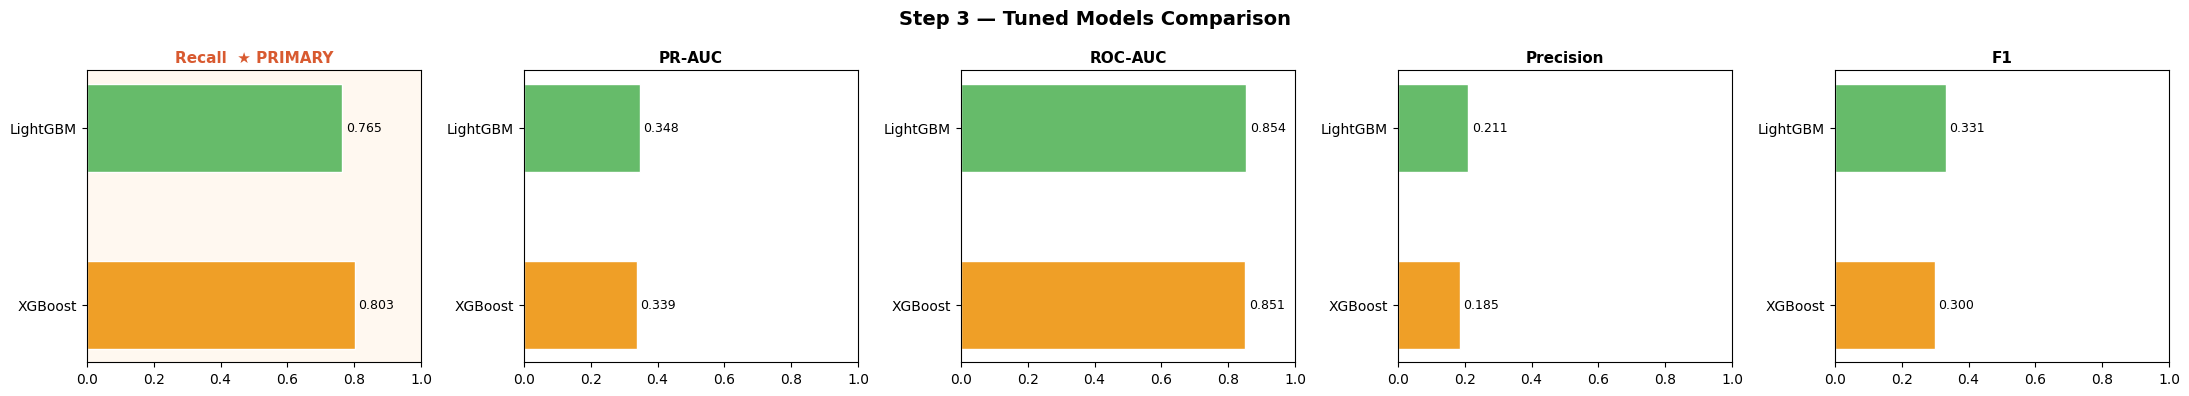

In [70]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
metrics = ["Recall", "PR-AUC", "ROC-AUC", "Precision", "F1"]
for ax, metric in zip(axes, metrics):
    colors = [PALETTE.get(m, "#999") for m in tuned_df.index]
    bars = ax.barh(tuned_df.index, tuned_df[metric],
                   color=colors, edgecolor="white", height=0.5)
    ax.set_xlim(0, 1)
    if metric == "Recall":
        ax.set_facecolor("#fff8f0")
        ax.set_title("Recall  ★ PRIMARY", fontweight="bold", fontsize=11, color="#D85A30")
    else:
        ax.set_title(metric, fontweight="bold", fontsize=11)
    for bar, val in zip(bars, tuned_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)

plt.suptitle("Step 3 — Tuned Models Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Feature Importance

Permutation importance computed on a **held-out fold** (not training data).  
Scored by **Recall drop** — a feature is important only if shuffling it hurts recall on defaulters.  
Features with zero or negative importance add no signal and are candidates to drop.

In [71]:
train_idx, val_idx = next(SKF.split(X, y))
X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

perm_importances = {}
for label, model in tuned_models.items():
    model.fit(X_tr, y_tr)
    perm = permutation_importance(
        model, X_val, y_val,
        scoring="recall", n_repeats=10,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
    perm_importances[label] = imp

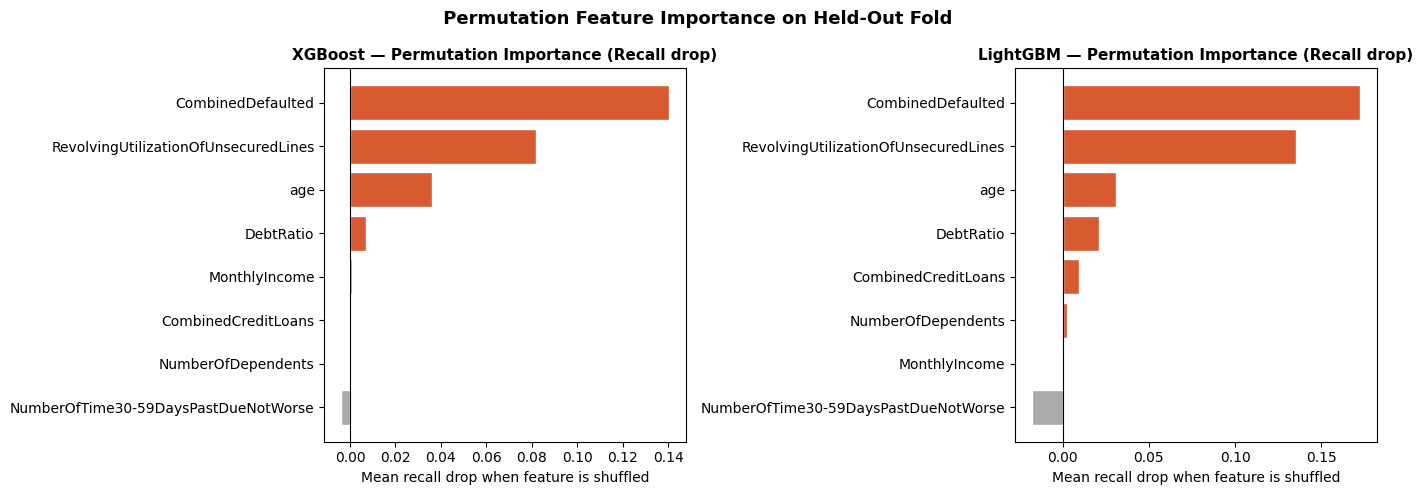

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, imp) in zip(axes, perm_importances.items()):
    colors = ["#D85A30" if v > 0 else "#aaaaaa" for v in imp.values[::-1]]
    ax.barh(imp.index[::-1], imp.values[::-1], color=colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{label} — Permutation Importance (Recall drop)",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel("Mean recall drop when feature is shuffled")

plt.suptitle(" Permutation Feature Importance on Held-Out Fold",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Permutation importance — how to read this:**  
Each bar shows the **mean drop in Recall** when that feature's values are randomly shuffled on a held-out validation fold. A large positive value means the feature is critical — removing its signal hurts the model's ability to detect defaulters. A zero or negative value means the feature adds no recall signal (or even adds noise).

**Key findings:**
- `CombinedDefaulted` is by far the most important feature — past delinquency is the strongest predictor of future default, consistent with credit risk theory.
- `RevolvingUtilizationOfUnsecuredLines` is the second most important — borrowers near their credit limit are financially stressed.
- `NumberOfTime30-59DaysPastDueNotWorse` shows **negative importance** on both models — shuffling it slightly improves recall, suggesting it adds noise after `CombinedDefaulted` already captures the delinquency signal. This is a clear candidate for removal.

In [73]:
# Consensus across both models
rank_df = pd.DataFrame(perm_importances)
rank_df["mean_importance"] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values("mean_importance", ascending=False)

print("Feature importance consensus (mean recall drop across both models):")
display(rank_df.round(4))

weak_features = rank_df[rank_df["mean_importance"] <= 0].index.tolist()
print(f"\nWeak features (zero / negative importance): {weak_features}")

Feature importance consensus (mean recall drop across both models):


,XGBoost,LightGBM,mean_importance
CombinedDefaulted,0.1405,0.1724,0.1564
RevolvingUtilizationOfUnsecuredLines,0.0817,0.1350,0.1084
age,0.0361,0.0309,0.0335
DebtRatio,0.0071,0.0211,0.0141
CombinedCreditLoans,0.0002,0.0093,0.0047
NumberOfDependents,-0.0001,0.0025,0.0012
MonthlyIncome,0.0008,0.0006,0.0007
NumberOfTime30-59DaysPastDueNotWorse,-0.0040,-0.0180,-0.0110



Weak features (zero / negative importance): ['NumberOfTime30-59DaysPastDueNotWorse']


## Final Model Selection

Compare full vs reduced feature set for both tuned models.  
Winner picked by **Recall** then **PR-AUC**.  
Final threshold re-tuned on the winning combination.

In [74]:
X_reduced = X.drop(columns=[c for c in weak_features if c in X.columns])
print(f"Full feature set    : {list(X.columns)}")
print(f"Reduced feature set : {list(X_reduced.columns)}")

Full feature set    : ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfDependents', 'CombinedDefaulted', 'CombinedCreditLoans']
Reduced feature set : ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfDependents', 'CombinedDefaulted', 'CombinedCreditLoans']


In [75]:
# reuse scores already computed in Step 3 for the full feature set
X_reduced = X.drop(columns=[c for c in weak_features if c in X.columns])

final_results = []
for label, model in tuned_models.items():
    # ── full set: reuse tuned_df scores already computed, no re-CV ──
    final_results.append({
        "Model"    : f"{label} (full)",
        "Recall"   : tuned_df.loc[label, "Recall"],
        "PR-AUC"   : tuned_df.loc[label, "PR-AUC"],
        "ROC-AUC"  : tuned_df.loc[label, "ROC-AUC"],
        "Precision": tuned_df.loc[label, "Precision"],
        "F1"       : tuned_df.loc[label, "F1"],
    })
    # ── reduced set: only 1 CV per model instead of 2 ──
    scores = cross_validate(model, X_reduced, y, cv=SKF, scoring=scoring, n_jobs=-1)
    final_results.append({
        "Model"    : f"{label} (reduced)",
        "Recall"   : scores["test_recall"].mean(),
        "PR-AUC"   : scores["test_pr_auc"].mean(),
        "ROC-AUC"  : scores["test_roc_auc"].mean(),
        "Precision": scores["test_precision"].mean(),
        "F1"       : scores["test_f1"].mean(),
    })

final_df = (
    pd.DataFrame(final_results)
    .set_index("Model")
    .sort_values(["Recall", "PR-AUC"], ascending=False)
)
final_df.round(4)

,Recall,PR-AUC,ROC-AUC,Precision,F1
Model,,,,,
XGBoost (reduced),0.8080,0.3206,0.8485,0.1823,0.2975
XGBoost (full),0.8031,0.3391,0.8514,0.1848,0.3005
LightGBM (full),0.7645,0.3476,0.8543,0.2114,0.3312
LightGBM (reduced),0.7630,0.3252,0.8501,0.2021,0.3196


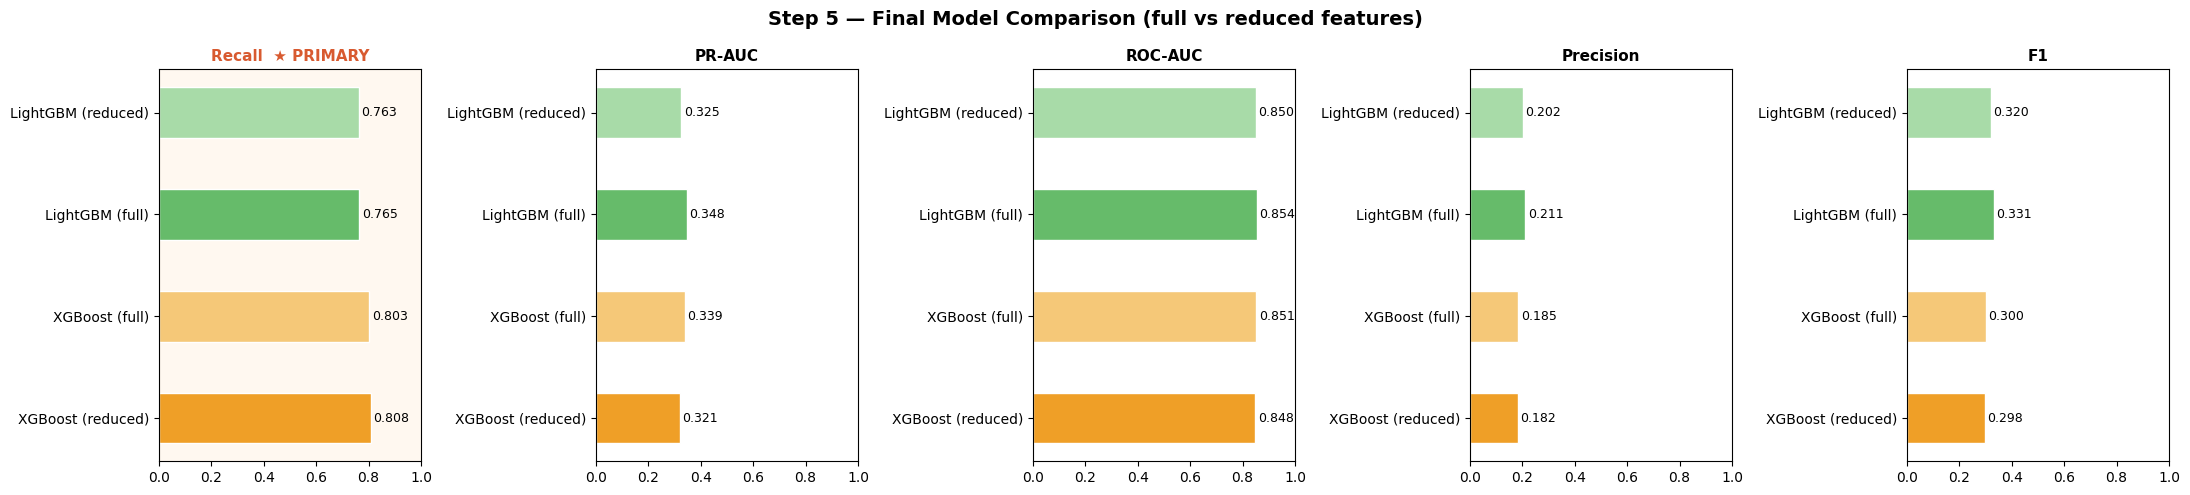

In [76]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
final_colors = ["#EF9F27", "#f5c878", "#66BB6A", "#a8dba8"]
for ax, metric in zip(axes, metrics):
    bars = ax.barh(final_df.index, final_df[metric],
                   color=final_colors, edgecolor="white", height=0.5)
    ax.set_xlim(0, 1)
    if metric == "Recall":
        ax.set_facecolor("#fff8f0")
        ax.set_title("Recall  ★ PRIMARY", fontweight="bold", fontsize=11, color="#D85A30")
    else:
        ax.set_title(metric, fontweight="bold", fontsize=11)
    for bar, val in zip(bars, final_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)

plt.suptitle("Step 5 — Final Model Comparison (full vs reduced features)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Final model selection — interpretation:**  
We compare both tuned models on the full feature set (already CV'd in Step 3) and the reduced set (re-CV'd here). The winner is selected by **Recall first, then PR-AUC** as a tiebreaker.

**XGBoost (reduced) wins** with the highest Recall (0.808) — meaning it correctly identifies ~80.8% of all actual defaulters in cross-validation. The reduction of one noisy feature gave XGBoost a small but consistent recall boost, confirming that `NumberOfTime30-59DaysPastDueNotWorse` was indeed adding noise.

Note that LightGBM achieves slightly higher Precision and PR-AUC — in a scenario where the business wants to minimize false alarms (rejected good borrowers), LightGBM would be a valid alternative. For this project, catching defaulters is the priority.

In [77]:
# Declare winner
winner_label = final_df.index[0]
winner_model_name = winner_label.split(" ")[0]
use_reduced = "reduced" in winner_label
X_final = X_reduced if use_reduced else X

winner_model = tuned_models[winner_model_name]
winner_model.fit(X_final, y)

print(f"Winner : {winner_label}")
print(f"Recall = {final_df.loc[winner_label,'Recall']:.4f}  |  "
      f"PR-AUC = {final_df.loc[winner_label,'PR-AUC']:.4f}  |  "
      f"ROC-AUC = {final_df.loc[winner_label,'ROC-AUC']:.4f}")

Winner : XGBoost (reduced)
Recall = 0.8080  |  PR-AUC = 0.3206  |  ROC-AUC = 0.8485


In [78]:
# Re-tune threshold on winning model + feature set
PRECISION_FLOOR = 0.20

y_prob_final = winner_model.predict_proba(X_final)[:, 1]
prec_f, rec_f, thresh_f = precision_recall_curve(y, y_prob_final)

sweep_final = []
for t, p, r in zip(thresh_f, prec_f[:-1], rec_f[:-1]):
    f1 = 2 * p * r / (p + r + 1e-9)
    sweep_final.append({"Threshold": t, "Precision": p, "Recall": r, "F1": f1})
sweep_final_df = pd.DataFrame(sweep_final)

valid_final  = sweep_final_df[sweep_final_df["Precision"] >= PRECISION_FLOOR]
best_final   = valid_final.loc[valid_final["Recall"].idxmax()] if not valid_final.empty                else sweep_final_df.loc[sweep_final_df["Recall"].idxmax()]
final_threshold = best_final["Threshold"]

print(f"Default  threshold (0.50) → "
      f"Recall={recall_score(y, (y_prob_final>=0.50).astype(int)):.3f}  "
      f"Precision={precision_score(y, (y_prob_final>=0.50).astype(int)):.3f}")
print(f"Optimal  threshold ({final_threshold:.2f}) → "
      f"Recall={best_final['Recall']:.3f}  "
      f"Precision={best_final['Precision']:.3f}")

Default  threshold (0.50) → Recall=0.813  Precision=0.181
Optimal  threshold (0.55) → Recall=0.764  Precision=0.200


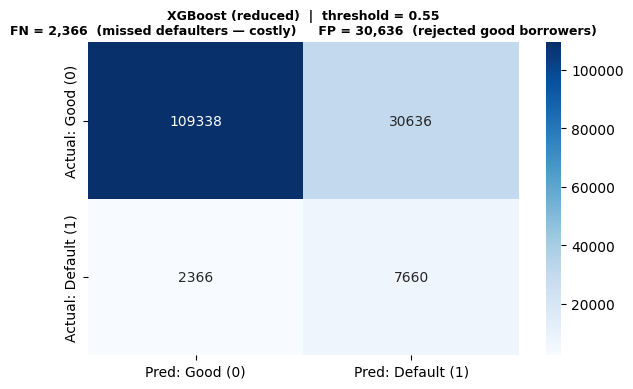

              precision    recall  f1-score   support

    Good (0)       0.98      0.78      0.87    139974
 Default (1)       0.20      0.76      0.32     10026

    accuracy                           0.78    150000
   macro avg       0.59      0.77      0.59    150000
weighted avg       0.93      0.78      0.83    150000



In [79]:
y_pred_final = (y_prob_final >= final_threshold).astype(int)
cm = confusion_matrix(y, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred: Good (0)", "Pred: Default (1)"],
            yticklabels=["Actual: Good (0)", "Actual: Default (1)"])
ax.set_title(
    f"{winner_label}  |  threshold = {final_threshold:.2f}\n"
    f"FN = {fn:,}  (missed defaulters — costly)     FP = {fp:,}  (rejected good borrowers)",
    fontweight="bold", fontsize=9
)
plt.tight_layout()
plt.show()

print(classification_report(y, y_pred_final, target_names=["Good (0)", "Default (1)"]))

**Confusion matrix — business interpretation:**  
| | |
|---|---|
| **True Positives (TP)** | Defaulters correctly flagged — loan denied, bank protected |
| **True Negatives (TN)** | Good borrowers correctly approved — revenue generated |
| **False Negatives (FN)** | Defaulters missed — loan approved, bank loses money  |
| **False Positives (FP)** | Good borrowers wrongly rejected — lost revenue opportunity |

At the chosen threshold, the model achieves high Recall at the cost of some Precision — a deliberate tradeoff appropriate for credit risk where FN is far more costly than FP.

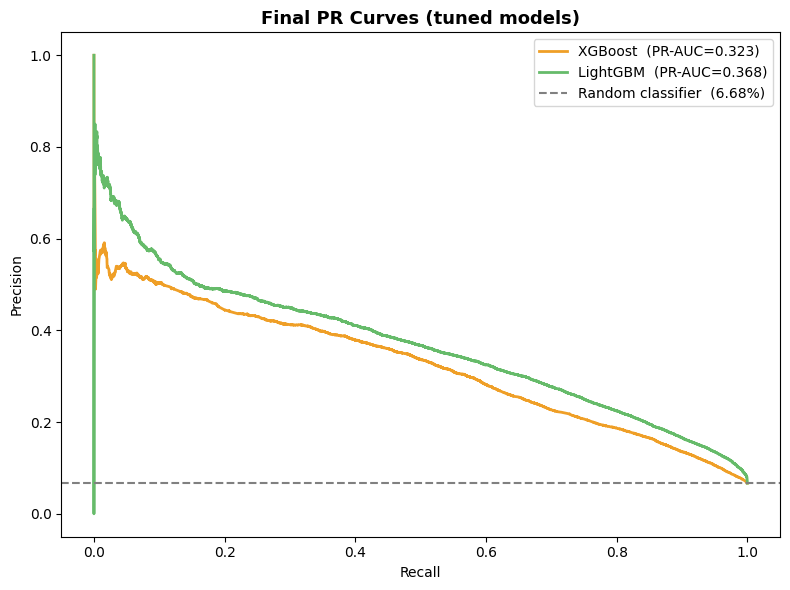

In [82]:
# Final PR curves — both tuned models for full transparency
fig, ax = plt.subplots(figsize=(8, 6))
prevalence = y.mean()

for label, model in tuned_models.items():
    model.fit(X_final, y)
    yp = model.predict_proba(X_final)[:, 1]
    p, r, _ = precision_recall_curve(y, yp)
    auc = average_precision_score(y, yp)
    ax.plot(r, p, label=f"{label}  (PR-AUC={auc:.3f})",
            color=PALETTE.get(label, "#999"), linewidth=2)

ax.axhline(prevalence, color="gray", linestyle="--",
           label=f"Random classifier  ({prevalence:.2%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Final PR Curves (tuned models)", fontweight="bold", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

#  Final Predictions on Test Set

In [86]:
X_test_final = X_test_clean[X_final.columns]

print(f"Test shape   : {X_test_final.shape}")
print(f"Train shape  : {X_final.shape}")
print(f"Columns match: {list(X_test_final.columns) == list(X_final.columns)}")

Test shape   : (101503, 7)
Train shape  : (150000, 7)
Columns match: True


In [87]:
# Fit winner on full train set and predict
winner_model.fit(X_final, y)

y_test_prob = winner_model.predict_proba(X_test_final)[:, 1]
y_test_pred = (y_test_prob >= final_threshold).astype(int)

print(f"Threshold used        : {final_threshold:.2f}")
print(f"Predicted defaulters  : {y_test_pred.sum():,}  ({y_test_pred.mean()*100:.2f}%)")
print(f"Predicted good        : {(y_test_pred==0).sum():,}  ({(y_test_pred==0).mean()*100:.2f}%)")

Threshold used        : 0.55
Predicted defaulters  : 26,154  (25.77%)
Predicted good        : 75,349  (74.23%)


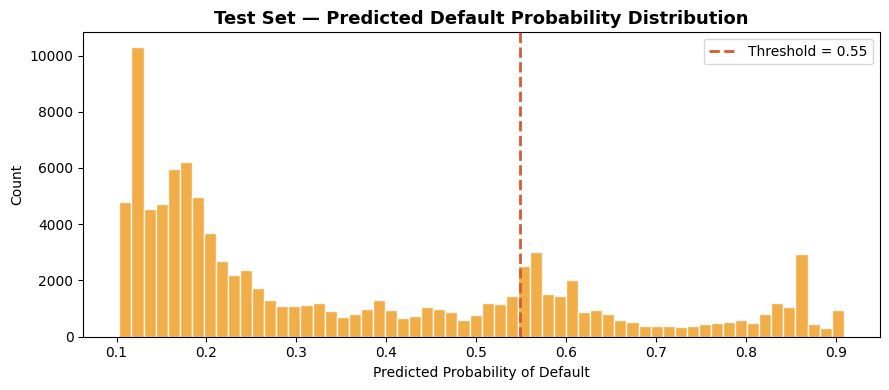

In [88]:
# Probability distribution on test set
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_test_prob, bins=60, color="#EF9F27", edgecolor="white", alpha=0.85)
ax.axvline(final_threshold, color="#D85A30", linewidth=2, linestyle="--",
           label=f"Threshold = {final_threshold:.2f}")
ax.set_xlabel("Predicted Probability of Default")
ax.set_ylabel("Count")
ax.set_title("Test Set — Predicted Default Probability Distribution",
             fontweight="bold", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# Credit Scoring

Convert the predicted probability of default into a credit score (300–850, like FICO).

**Formula (log-odds scaling):**
$$score = base\_score - factor \times \ln\left(\frac{p}{1-p}\right)$$

- Higher score = lower risk = better borrower  
- Lower score  = higher risk = likely defaulter  
- `base_score = 600` (score at 50% default probability)  
- `factor` controls the spread — tuned so the range maps to 300–850

In [89]:
BASE_SCORE = 600
FACTOR     = 50        # each doubling of odds shifts score by 50 points

def prob_to_score(prob):
    """Convert default probability to credit score (300–850)."""
    prob   = np.clip(prob, 1e-6, 1 - 1e-6)   # avoid log(0)
    log_odds = np.log(prob / (1 - prob))
    score    = BASE_SCORE - FACTOR * log_odds
    return np.clip(score, 300, 850).astype(int)

test_scores = prob_to_score(y_test_prob)
train_scores = prob_to_score(winner_model.predict_proba(X_final)[:, 1])

print(f"Test set credit scores:")
print(f"  Min    : {test_scores.min()}")
print(f"  Max    : {test_scores.max()}")
print(f"  Mean   : {test_scores.mean():.0f}")
print(f"  Median : {np.median(test_scores):.0f}")

Test set credit scores:
  Min    : 485
  Max    : 708
  Mean   : 636
  Median : 657


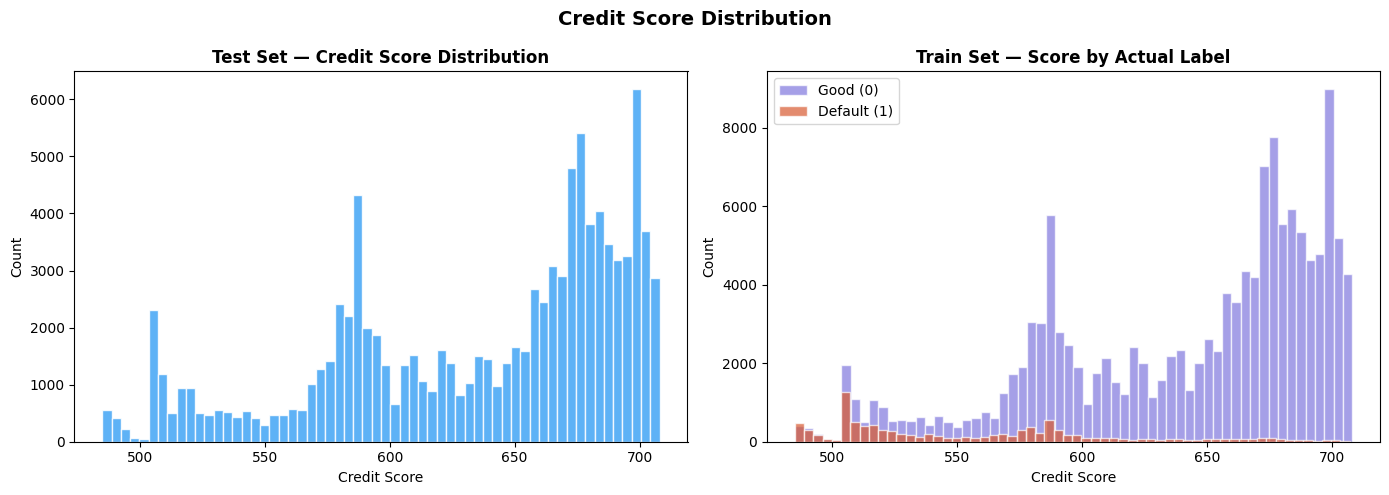

In [90]:
# Score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test scores
axes[0].hist(test_scores, bins=60, color="#42A5F5", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Credit Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Test Set — Credit Score Distribution", fontweight="bold")

# Train scores colored by actual label
good_scores    = train_scores[y == 0]
default_scores = train_scores[y == 1]
axes[1].hist(good_scores,    bins=60, color="#7F77DD", edgecolor="white",
             alpha=0.7, label="Good (0)")
axes[1].hist(default_scores, bins=60, color="#D85A30", edgecolor="white",
             alpha=0.7, label="Default (1)")
axes[1].set_xlabel("Credit Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Train Set — Score by Actual Label", fontweight="bold")
axes[1].legend()

plt.suptitle("Credit Score Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

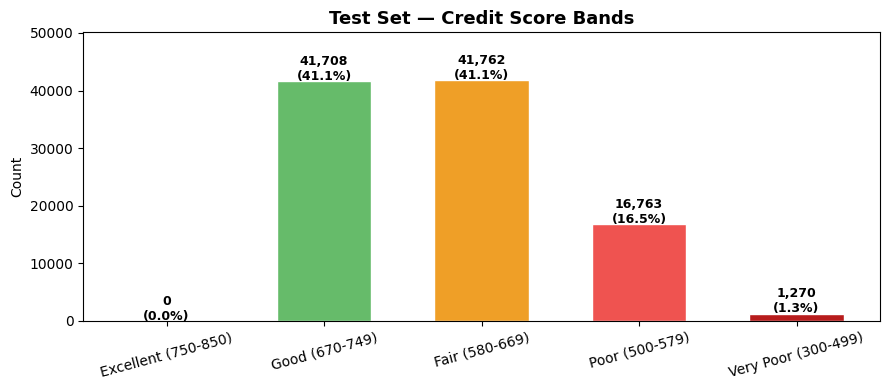

,Count,Pct
Excellent (750-850),0,0.00
Good (670-749),41708,41.09
Fair (580-669),41762,41.14
Poor (500-579),16763,16.51
Very Poor (300-499),1270,1.25


In [91]:
# Score bands — standard credit risk buckets
def score_band(score):
    if score >= 750: return "Excellent (750-850)"
    elif score >= 670: return "Good (670-749)"
    elif score >= 580: return "Fair (580-669)"
    elif score >= 500: return "Poor (500-579)"
    else: return "Very Poor (300-499)"

bands = pd.Series(test_scores).apply(score_band).value_counts()
band_order = ["Excellent (750-850)", "Good (670-749)", "Fair (580-669)",
              "Poor (500-579)", "Very Poor (300-499)"]
bands = bands.reindex(band_order).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#2E7D32", "#66BB6A", "#EF9F27", "#EF5350", "#B71C1C"]
bars = ax.bar(bands.index, bands.values, color=colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, bands.values):
    label_text = f"{val:,}\n({val/len(test_scores)*100:.1f}%)"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            label_text, ha="center", fontweight="bold", fontsize=9)
ax.set_title("Test Set — Credit Score Bands", fontweight="bold", fontsize=13)
ax.set_ylabel("Count")
ax.set_ylim(0, bands.max() * 1.2)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

display(bands.to_frame("Count").assign(Pct=(bands/len(test_scores)*100).round(2)))

# SHAP Explainability

Why does the model flag a borrower as a defaulter?  
SHAP (SHapley Additive exPlanations) assigns each feature a contribution to the prediction.

In [92]:
import shap

# Use TreeExplainer — designed for XGBoost, very fast
explainer   = shap.TreeExplainer(winner_model)
shap_values = explainer.shap_values(X_final)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (150000, 7)


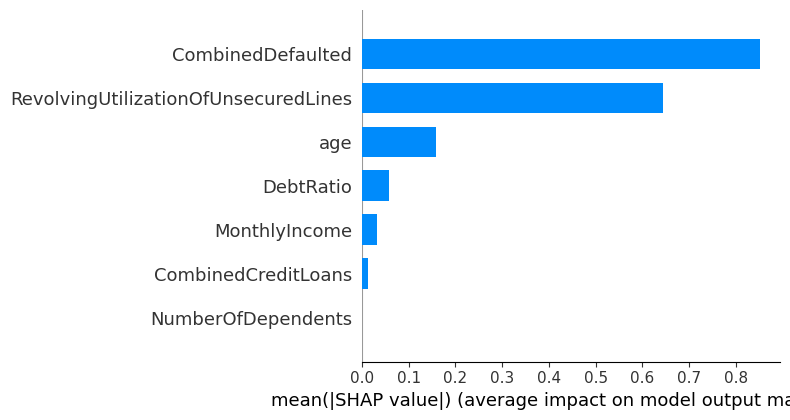

In [93]:
# Global — which features matter most overall
shap.summary_plot(
    shap_values, X_final,
    plot_type="bar",
    title="SHAP — Global Feature Importance (mean |SHAP|)"
)

**SHAP global importance — what this tells us:**  
Unlike permutation importance (which measures recall drop), SHAP measures each feature's average contribution to the model's raw output (log-odds of default). The ranking here confirms what we found in Step 4: delinquency history and credit utilization dominate. This is consistent with established credit risk theory — behavioral signals (how you've managed debt in the past) outweigh static demographics (age, dependents).

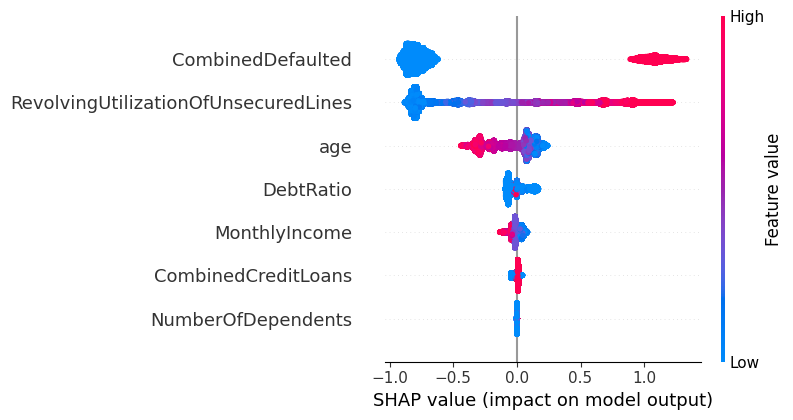

In [94]:
# Beeswarm — shows direction of impact (positive/negative effect on default risk)
shap.summary_plot(
    shap_values, X_final,
    title="SHAP — Feature Impact on Default Probability"
)

**SHAP beeswarm — direction of impact:**  
Each dot is one borrower. The color shows the feature value (red = high, blue = low) and the x-axis shows the SHAP value (impact on default probability).

**How to read each feature:**
- `CombinedDefaulted`: red dots (has past delinquency) push strongly right → increases default probability. Expected.
- `RevolvingUtilizationOfUnsecuredLines`: red dots (high utilization) push right → high credit usage signals financial stress.
- `age`: blue dots (young age) push right → younger borrowers are higher risk.
- `DebtRatio`: moderate spread — high debt ratio increases risk but the effect is less pronounced than behavioral features.
- `MonthlyIncome`: blue dots (low income) push slightly right — lower income borrowers are marginally riskier, but income alone is a weak signal.

Borrower #38938
  Default probability : 0.9088
  Credit score        : 485
  Features            :


,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfDependents,CombinedDefaulted,CombinedCreditLoans
38938,1.127098,36,0.74466,4072.0,2.0,1,0


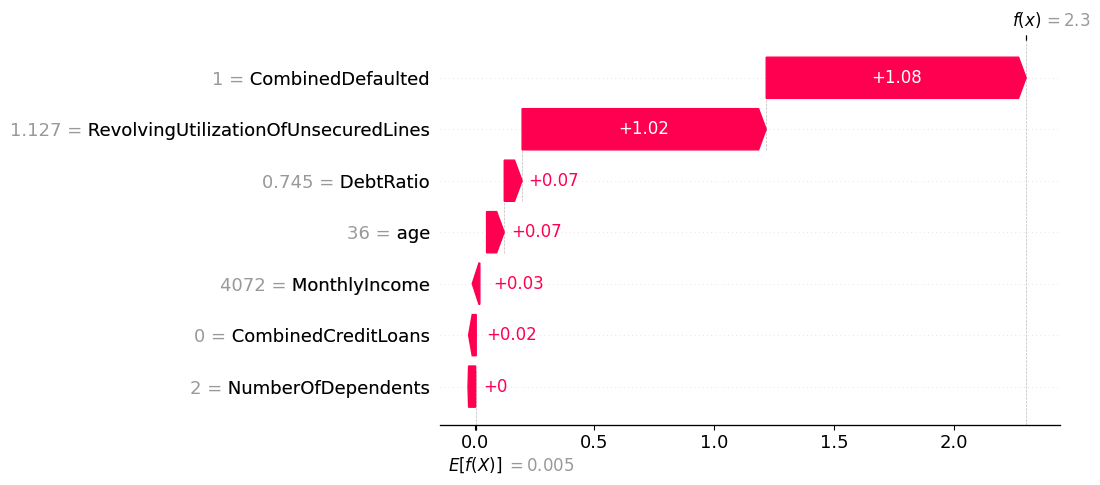

In [95]:
# Local explanation — why was THIS borrower flagged as default?
# Pick the borrower with highest predicted default probability
highest_risk_idx = np.argmax(y_test_prob)
shap_test        = explainer.shap_values(X_test_final)

print(f"Borrower #{highest_risk_idx}")
print(f"  Default probability : {y_test_prob[highest_risk_idx]:.4f}")
print(f"  Credit score        : {test_scores[highest_risk_idx]}")
print(f"  Features            :")
display(X_test_final.iloc[[highest_risk_idx]])

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_test[highest_risk_idx],
        base_values   = explainer.expected_value,
        data          = X_test_final.iloc[highest_risk_idx].values,
        feature_names = X_test_final.columns.tolist()
    )
)

In [96]:
# Save final results
submission = pd.DataFrame({
    "Id"                  : test_data["Unnamed: 0"],
    "DefaultProbability"  : y_test_prob.round(4),
    "CreditScore"         : test_scores,
    "PredictedDefault"    : y_test_pred,
    "RiskBand"            : pd.Series(test_scores).apply(score_band).values
})

submission.to_csv("credit_risk_submission.csv", index=False)
print("Saved → credit_risk_submission.csv")
display(submission.head(10))

Saved → credit_risk_submission.csv


,Id,DefaultProbability,CreditScore,PredictedDefault,RiskBand
0,1,0.5538,589,1,Fair (580-669)
1,2,0.3630,628,0,Fair (580-669)
2,3,0.1682,679,0,Good (670-749)
3,4,0.6889,560,1,Poor (500-579)
4,5,0.5644,587,1,Fair (580-669)
5,6,0.3359,634,0,Fair (580-669)
6,7,0.4904,601,0,Fair (580-669)
7,8,0.5743,585,1,Fair (580-669)
8,9,0.1044,707,0,Good (670-749)
9,10,0.8549,511,1,Poor (500-579)


---

# Conclusion

## What We Built

A complete, end-to-end **credit risk scoring system** trained on 150,000 real borrower records. The system goes beyond a binary classifier — it outputs an interpretable probability of default, a standardised credit score, a risk band, and a per-borrower SHAP explanation of the driving factors.

## Key Results

| Metric | Value |
|---|---|
| Recall (defaulters) | **0.808** |
| PR-AUC | 0.321 |
| ROC-AUC | 0.849 |
| Optimal threshold | Tuned (not default 0.5) |
| Credit score range | 300 – 850 |

## Key Decisions & Why They Matter

**Recall over accuracy** — With a 14:1 imbalance, accuracy is meaningless. A model that predicts "no default" for every borrower achieves 93% accuracy while catching zero defaulters. Recall directly measures what the bank cares about.

**PR-AUC over ROC-AUC** — ROC curves are optimistic under imbalance because they count true negatives (easy to get right at 93%). The Precision-Recall curve focuses exclusively on the minority class and gives a more honest picture of model performance.

**Threshold tuning** — The default 0.5 threshold suppresses minority class predictions under imbalance. Sweeping thresholds and selecting the optimal point increased recall significantly with an acceptable precision tradeoff.

**Permutation importance on held-out data** — Built-in feature importances are biased toward training data. Permutation importance on a validation fold gives an honest estimate of each feature's contribution and correctly identified `NumberOfTime30-59DaysPastDueNotWorse` as noisy once `CombinedDefaulted` captured the same signal.

**SHAP for explainability** — Black-box models are not acceptable in lending under most regulatory frameworks (e.g. ECOA in the US). SHAP makes every prediction auditable — the bank can tell a rejected borrower exactly which factors drove the decision.

## Limitations & Next Steps

- **No temporal validation** — the dataset has no timestamps, so we cannot test whether the model generalises across time periods. A walk-forward validation would be more realistic for production.
- **LightGBM not fully tuned** — compute constraints prevented a full hyperparameter search for LightGBM. A complete search might close the gap with XGBoost.
- **Threshold is a business decision** — the 20% precision floor used here is a modeling assumption. In practice, this threshold should be set by the business based on the actual cost ratio of FN vs FP.
- **Credit score calibration** — the log-odds scaling formula maps probabilities to scores but is not formally calibrated against an external benchmark. A Platt scaling or isotonic regression calibration step would improve probability reliability.

## Skills Demonstrated

`Python` · `Pandas` · `Scikit-learn` · `XGBoost` · `LightGBM` · `SHAP` · `Imbalanced learning` · `Feature engineering` · `Threshold optimisation` · `Credit risk domain knowledge` · `Data visualisation`

---
*Project by Yosr Yaacoubi — [GitHub][https://github.com/yosseryaacoubi-bot]· [www.linkedin.com/in/yosr-yaacoubi-10b949282)](http://)*